In [1]:
try:
    import google.colab  # noqa: F401

    # specify the version of DataEval (==X.XX.X) for versions other than the latest
    %pip install -q dataeval maite-datasets matplotlib
except Exception:
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from maite_datasets.object_detection import SeaDrone

from dataeval import Metadata
from dataeval.bias import Balance
from dataeval.config import set_max_processes
from dataeval.core import compute_ratios, compute_stats
from dataeval.data import Limit, View
from dataeval.flags import ImageStats

set_max_processes(4)

# Show every row of the comparison tables below rather than polars' default window - the
# rows this guide reasons about would otherwise be the ones elided.
pl.Config.set_tbl_rows(20)

polars.config.Config

In [3]:
dataset = View(SeaDrone(root="./data", image_set="val", download=True), Limit(120))

print(f"Images: {len(dataset)}")
print(f"Image shape: {dataset[0][0].shape}")

Images: 120
Image shape: (3, 933, 1230)


In [4]:
stats = compute_stats(
    dataset,
    stats=ImageStats.VISUAL_BRIGHTNESS | ImageStats.VISUAL_CONTRAST | ImageStats.DIMENSION_SIZE,
    per_image=True,
    per_target=True,
    per_background=True,
    normalize_pixel_values=False,
)

print(sorted(stats["stats"]))

['background_brightness', 'background_contrast', 'background_fraction', 'brightness', 'contrast', 'size']


In [5]:
metadata = Metadata(dataset)
metadata.add_factors(stats)

print(sorted(n for n in metadata.factor_names if "brightness" in n or "fraction" in n))

['instance_brightness', 'unit_background_brightness', 'unit_background_fraction', 'unit_brightness']


In [6]:
print(dict(metadata.dropped_factors))

{'instance_background_brightness': ['no_values_at_level'], 'instance_background_contrast': ['no_values_at_level'], 'instance_background_fraction': ['no_values_at_level']}


In [7]:
units = metadata.rows_at("unit")
coverage = units["unit_background_fraction"]

print(f"background fraction  min {coverage.min():.3f}   median {coverage.median():.3f}   max {coverage.max():.3f}")

background fraction  min 0.927   median 0.998   max 1.000


In [8]:
drift = (units["unit_background_brightness"] - units["unit_brightness"]).abs().mean()
print(f"mean |background - whole image| brightness: {drift:.3f}")

mean |background - whole image| brightness: 0.017


In [9]:
labels = metadata.index2label
detections = metadata.rows_at("instance").with_columns(
    (pl.col("instance_brightness") - pl.col("unit_background_brightness")).alias("separation"),
    pl.col("class_label").replace_strict(labels, return_dtype=pl.Utf8).alias("class_name"),
)

by_class = (
    detections
    .group_by("class_name")
    .agg(
        pl.len().alias("n"),
        pl.col("separation").mean().round(1).alias("mean_separation"),
        pl.col("separation").std().round(1).alias("sd"),
        pl.col("instance_size").median().alias("median_px"),
    )
    .sort("mean_separation")
)
print(by_class)

shape: (5, 5)
┌────────────────────────┬─────┬─────────────────┬───────────┬───────────┐
│ class_name             ┆ n   ┆ mean_separation ┆ sd        ┆ median_px │
│ ---                    ┆ --- ┆ ---             ┆ ---       ┆ ---       │
│ str                    ┆ u32 ┆ f32             ┆ f32       ┆ f32       │
╞════════════════════════╪═════╪═════════════════╪═══════════╪═══════════╡
│ buoy                   ┆ 11  ┆ -6.8            ┆ 7.4       ┆ 1155.0    │
│ jetski                 ┆ 7   ┆ 1.6             ┆ 10.7      ┆ 2262.0    │
│ life_saving_appliances ┆ 8   ┆ 8.8             ┆ 20.799999 ┆ 195.0     │
│ swimmer                ┆ 190 ┆ 18.299999       ┆ 19.299999 ┆ 600.0     │
│ boat                   ┆ 213 ┆ 24.6            ┆ 20.799999 ┆ 8494.0    │
└────────────────────────┴─────┴─────────────────┴───────────┴───────────┘


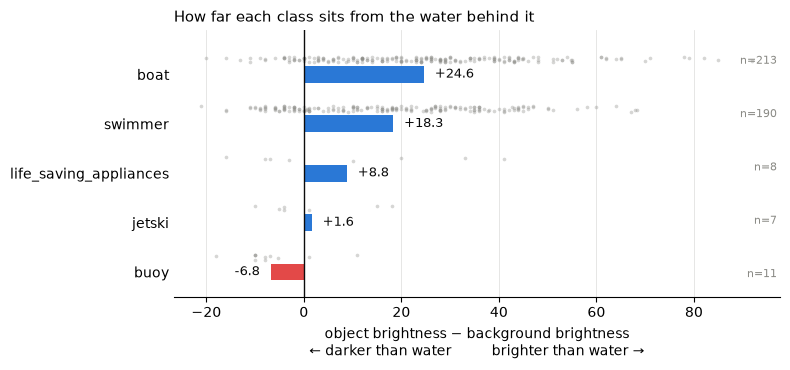

In [10]:
# Diverging bars around a meaningful zero: color encodes the sign, length the magnitude.
# The per-detection spread rides in its own band above each bar rather than on top of it,
# so neither the marks nor the value labels are read through a cloud of dots.
BRIGHTER, DARKER, INK, MUTED = "#2a78d6", "#e34948", "#0b0b0b", "#8a8a85"

ordered = by_class.sort("mean_separation")
names = ordered["class_name"].to_list()
means = ordered["mean_separation"].to_numpy()
counts = ordered["n"].to_list()
y = np.arange(len(names))

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 3.8))

ax.barh(y, means, height=0.34, color=[BRIGHTER if m > 0 else DARKER for m in means], zorder=3)
for i, name in enumerate(names):
    pts = detections.filter(pl.col("class_name") == name)["separation"].to_numpy()
    jitter = rng.uniform(-0.055, 0.055, len(pts))
    ax.scatter(pts, i + 0.30 + jitter, s=7, color=MUTED, alpha=0.35, linewidths=0, zorder=2)

ax.axvline(0, color=INK, linewidth=1, zorder=4)

separation = detections["separation"].to_numpy()
pad = 0.02 * (separation.max() - separation.min())
for i, (m, n) in enumerate(zip(means, counts, strict=True)):
    ax.text(
        m + (pad if m > 0 else -pad),
        i,
        f"{m:+.1f}",
        va="center",
        ha="left" if m > 0 else "right",
        fontsize=9,
        color=INK,
        zorder=5,
    )
    ax.text(
        0.995,
        (i + 0.42) / len(names),
        f"n={n}",
        transform=ax.transAxes,
        va="center",
        ha="right",
        fontsize=8,
        color=MUTED,
    )

ax.set_yticks(y, names)
ax.tick_params(axis="y", length=0)
ax.set_ylim(-0.5, len(names) - 0.1)
ax.set_xlabel("object brightness − background brightness\n← darker than water          brighter than water →")
ax.set_title("How far each class sits from the water behind it", loc="left", fontsize=11)
ax.grid(axis="x", color=MUTED, alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

In [11]:
camouflaged = detections.filter(pl.col("separation").abs() < 5)
print(
    f"{len(camouflaged)} of {len(detections)} detections ({len(camouflaged) / len(detections):.1%}) "
    f"are within ±5 brightness of their background"
)
print(camouflaged.group_by("class_name").agg(pl.len().alias("n")).sort("n", descending=True))

70 of 429 detections (16.3%) are within ±5 brightness of their background
shape: (5, 2)
┌────────────────────────┬─────┐
│ class_name             ┆ n   │
│ ---                    ┆ --- │
│ str                    ┆ u32 │
╞════════════════════════╪═════╡
│ swimmer                ┆ 34  │
│ boat                   ┆ 31  │
│ jetski                 ┆ 3   │
│ life_saving_appliances ┆ 1   │
│ buoy                   ┆ 1   │
└────────────────────────┴─────┘


In [12]:
print(camouflaged.select("item_index", "target_index", "class_name", "separation").head(8))

shape: (8, 4)
┌────────────┬──────────────┬────────────┬────────────┐
│ item_index ┆ target_index ┆ class_name ┆ separation │
│ ---        ┆ ---          ┆ ---        ┆ ---        │
│ i64        ┆ i64          ┆ str        ┆ f32        │
╞════════════╪══════════════╪════════════╪════════════╡
│ 0          ┆ 0            ┆ boat       ┆ 3.0        │
│ 2          ┆ 4            ┆ swimmer    ┆ -4.0       │
│ 6          ┆ 5            ┆ boat       ┆ -2.0       │
│ 10         ┆ 0            ┆ swimmer    ┆ 4.0        │
│ 10         ┆ 1            ┆ swimmer    ┆ 3.0        │
│ 13         ┆ 1            ┆ boat       ┆ -4.0       │
│ 17         ┆ 0            ┆ boat       ┆ 0.0        │
│ 17         ┆ 1            ┆ boat       ┆ 2.0        │
└────────────┴──────────────┴────────────┴────────────┘


In [13]:
ratios = compute_ratios(stats)
print(sorted(ratios["stats"]))

['brightness', 'contrast', 'size']


In [14]:
relative = Metadata(dataset)
relative.add_factors({f"relative_{k}": v for k, v in ratios["stats"].items()}, source_index=ratios["source_index"])

comparison = (
    relative
    .rows_at("instance")
    .with_columns(pl.col("class_label").replace_strict(labels, return_dtype=pl.Utf8).alias("class_name"))
    .group_by("class_name")
    .agg(
        pl.len().alias("n"),
        pl.col("relative_brightness").mean().round(3).alias("brightness_vs_image"),
        pl.col("relative_contrast").mean().round(3).alias("contrast_vs_image"),
        pl.col("relative_size").mean().round(4).alias("size_vs_image"),
    )
    .sort("brightness_vs_image")
)
print(comparison)

shape: (5, 5)
┌────────────────────────┬─────┬─────────────────────┬───────────────────┬───────────────┐
│ class_name             ┆ n   ┆ brightness_vs_image ┆ contrast_vs_image ┆ size_vs_image │
│ ---                    ┆ --- ┆ ---                 ┆ ---               ┆ ---           │
│ str                    ┆ u32 ┆ f32                 ┆ f32               ┆ f32           │
╞════════════════════════╪═════╪═════════════════════╪═══════════════════╪═══════════════╡
│ buoy                   ┆ 11  ┆ 0.824               ┆ 0.915             ┆ 0.0012        │
│ life_saving_appliances ┆ 8   ┆ 1.07                ┆ 0.769             ┆ 0.0001        │
│ jetski                 ┆ 7   ┆ 1.098               ┆ 0.807             ┆ 0.002         │
│ swimmer                ┆ 190 ┆ 1.229               ┆ 0.69              ┆ 0.0002        │
│ boat                   ┆ 213 ┆ 1.319               ┆ 0.681             ┆ 0.0021        │
└────────────────────────┴─────┴─────────────────────┴───────────────────┴──

In [15]:
capture_metadata = [
    "altitude",
    "compass_heading",
    "date_time",
    "drone",
    "frame",
    "gimbal_heading",
    "gimbal_pitch",
    "height",
    "id",
    "image_id",
    "latitude",
    "longitude",
    "object_id",
    "object_size",
    "speed",
    "storage",
    "width",
    "xspeed",
    "yspeed",
    "zspeed",
]
# One edge list per quantity, shared across the image, background, and box readings of it,
# so the three land on a single scale.
BRIGHTNESS_BINS = [0, 32, 64, 96, 128, 160, 192, 224, 255]
CONTRAST_BINS = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
FRACTION_BINS = [0.0, 0.9, 0.95, 0.99, 0.999, 1.0]
SIZE_BINS = [0, 316, 1000, 3162, 10000, 31623, 100000]

focused = Metadata(
    dataset,
    exclude=capture_metadata,
    continuous_factor_bins={
        "unit_brightness": BRIGHTNESS_BINS,
        "unit_background_brightness": BRIGHTNESS_BINS,
        "instance_brightness": BRIGHTNESS_BINS,
        "unit_contrast": CONTRAST_BINS,
        "unit_background_contrast": CONTRAST_BINS,
        "instance_contrast": CONTRAST_BINS,
        "unit_background_fraction": FRACTION_BINS,
        "instance_size": SIZE_BINS,
    },
)
focused.add_factors(stats)

classwise = (
    Balance()
    .evaluate(focused)
    .classwise.with_columns(pl.col("factor_name").cast(pl.Utf8), pl.col("class_name").cast(pl.Utf8))
    .filter(pl.col("factor_name").str.starts_with("unit_background"))
    .sort("factor_name", "class_name")
)
print(classwise)

shape: (15, 4)
┌────────────────────────┬────────────────────────────┬──────────┬───────────────┐
│ class_name             ┆ factor_name                ┆ mi_value ┆ is_imbalanced │
│ ---                    ┆ ---                        ┆ ---      ┆ ---           │
│ str                    ┆ str                        ┆ f64      ┆ bool          │
╞════════════════════════╪════════════════════════════╪══════════╪═══════════════╡
│ boat                   ┆ unit_background_brightness ┆ 0.035032 ┆ false         │
│ buoy                   ┆ unit_background_brightness ┆ 0.329079 ┆ true          │
│ jetski                 ┆ unit_background_brightness ┆ 0.149973 ┆ false         │
│ life_saving_appliances ┆ unit_background_brightness ┆ 0.058432 ┆ false         │
│ swimmer                ┆ unit_background_brightness ┆ 0.009779 ┆ false         │
│ boat                   ┆ unit_background_contrast   ┆ 0.014274 ┆ false         │
│ buoy                   ┆ unit_background_contrast   ┆ 0.224709 ┆ false

/tmp/ipykernel_7433/228014068.py:48: UserWarning: Declared cuts left bins unused: instance_brightness (6 of 8 bins hold rows), instance_contrast (6 of 7 bins hold rows), unit_background_brightness (4 of 8 bins hold rows), unit_background_contrast (6 of 7 bins hold rows), unit_background_fraction (4 of 5 bins hold rows), unit_brightness (4 of 8 bins hold rows), unit_contrast (5 of 7 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  .evaluate(focused)
